# Bloque II — Regresión y comparación de modelos (RESUELTO)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
df = pd.read_csv("ventas_mayo_2026.csv")
df.head()

,fecha,cliente_id,categoria,region,canal,unidades,precio_unitario,descuento,antiguedad_cliente_meses,importe
0,2025-01-01,C1000,Hogar,Madrid,Online,8,99.92,0.07,63,836.25
1,2025-01-02,C1001,Servicios,Madrid,Distribuidor,5,192.95,0.10,52,956.72
2,2025-01-03,C1002,Moda,Madrid,Online,7,39.77,0.05,26,357.65
3,2025-01-04,C1003,Alimentación,Valencia,Online,9,25.17,0.06,53,301.52
4,2025-01-05,C1004,Tecnología,Castilla-La Mancha,Distribuidor,8,NaN,0.09,29,2101.55


In [3]:
# Limpieza básica
df = df.drop_duplicates()
df["precio_unitario"] = df["precio_unitario"].fillna(df["precio_unitario"].median())
df["region"] = df["region"].fillna("Sin informar")

In [4]:
# Variables
df_model = pd.get_dummies(df, drop_first=True)

X = df_model.drop("importe", axis=1)
y = df_model["importe"]

In [5]:
# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [6]:
# Modelos
lr = LinearRegression()
dt = DecisionTreeRegressor(max_depth=5)

lr.fit(X_train, y_train)
dt.fit(X_train, y_train)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_le

In [7]:
# Predicciones
y_pred_lr = lr.predict(X_test)
y_pred_dt = dt.predict(X_test)

In [8]:
# Métricas
def evaluar(y_true, y_pred):
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R2": r2_score(y_true, y_pred)
    }

res_lr = evaluar(y_test, y_pred_lr)
res_dt = evaluar(y_test, y_pred_dt)

res_lr, res_dt

({'MAE': 232.87612610097455,
  'RMSE': np.float64(322.37151528079545),
  'R2': 0.8504085642045506},
 {'MAE': 185.152907212724,
  'RMSE': np.float64(267.76104853782505),
  'R2': 0.8967979772636605})

In [9]:
# Comparación
resultados = pd.DataFrame([res_lr, res_dt], index=["LinearRegression", "DecisionTree"])
resultados

,MAE,RMSE,R2
LinearRegression,232.876126,322.371515,0.850409
DecisionTree,185.152907,267.761049,0.896798


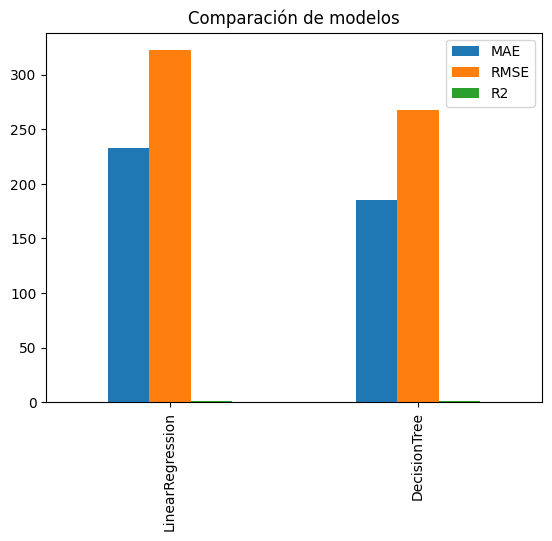

In [10]:
# Visualización
resultados.plot(kind="bar")
plt.title("Comparación de modelos")
plt.show()

## Conclusiones

In [11]:
mejor_modelo = resultados["R2"].idxmax()

print(f"El mejor modelo según R2 es: {mejor_modelo}")
print("Se recomienda usar este modelo para predicción.")

El mejor modelo según R2 es: DecisionTree
Se recomienda usar este modelo para predicción.
